# ANM Validation Across Multiple Protein Structures

This notebook validates the Cα Anisotropic Network Model (ANM) pipeline in
this repository against six real, experimentally determined protein
structures, by comparing ANM-predicted flexibility (mean-square fluctuation,
MSF) to each structure's own experimental B-factors.

The elastic network model treats a protein as a mass-and-spring network:
every Cα atom is a node, and any two Cα atoms within a cutoff distance are
connected by a spring of uniform stiffness. Diagonalizing the resulting
Hessian gives a set of normal modes; summing the low-frequency modes'
contributions predicts each residue's flexibility. This approach follows the
Anisotropic Network Model introduced by Atilgan, Durell, Jernigan, Demirel,
Keskin, and Bahar (*Biophysical Journal*, 2001), and later evaluated
systematically by Eyal, Yang, and Bahar (*Bioinformatics*, 2006).

**What this notebook checks:** does the model's prediction, built from
nothing but a static structure and a uniform spring constant, actually track
real experimental flexibility data -- and where does it agree or disagree?


In [1]:
import os
import sys
import urllib.request

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, os.path.abspath(".."))
import anm
from anm.validation import bfactor_to_msf

%matplotlib inline


## Protein test set

Six single-chain, X-ray crystal structures spanning a range of sizes and
known dynamics, all downloaded directly from the RCSB PDB:


In [2]:
PROTEINS = [
    {"id": "1CRN", "name": "Crambin",
     "note": "Very small, rigid plant seed protein; high-resolution benchmark structure."},
    {"id": "1UBQ", "name": "Ubiquitin",
     "note": "Small, extensively studied regulatory protein."},
    {"id": "1AKI", "name": "Hen egg-white lysozyme",
     "note": "Classic two-domain enzyme."},
    {"id": "1CTF", "name": "Ribosomal protein L7/L12 (C-terminal domain)",
     "note": "Small alpha/beta domain, widely used as a model system in protein folding studies."},
    {"id": "2LZM", "name": "T4 lysozyme",
     "note": "Two-domain enzyme known for hinge-bending motion between its domains."},
    {"id": "4AKE", "name": "Adenylate kinase (open form)",
     "note": "Three-domain enzyme with large-scale hinge motion; a classic showcase structure for normal mode analysis."},
]

pd.DataFrame(PROTEINS).set_index("id")


,name,note
id,,
1CRN,Crambin,"Very small, rigid plant seed protein; high-res..."
1UBQ,Ubiquitin,"Small, extensively studied regulatory protein."
1AKI,Hen egg-white lysozyme,Classic two-domain enzyme.
1CTF,Ribosomal protein L7/L12 (C-terminal domain),"Small alpha/beta domain, widely used as a mode..."
2LZM,T4 lysozyme,Two-domain enzyme known for hinge-bending moti...
4AKE,Adenylate kinase (open form),Three-domain enzyme with large-scale hinge mot...


## Running the pipeline

For each structure: download the PDB file (cached locally after the first
run), restrict to chain A, and run the full pipeline with default parameters
(`cutoff=8.0`, `gamma=1.0`, no PDF report -- this notebook *is* the report).


In [3]:
DOWNLOAD_DIR = "structures"
os.makedirs(DOWNLOAD_DIR, exist_ok=True)

results = {}
rows = []

for p in PROTEINS:
    pdb_id = p["id"]
    dest = os.path.join(DOWNLOAD_DIR, f"{pdb_id}.pdb")
    if not os.path.exists(dest):
        urllib.request.urlretrieve(f"https://files.rcsb.org/download/{pdb_id}.pdb", dest)

    result = anm.run_anm_pipeline(dest, chain_id="A", report_path=None)
    results[pdb_id] = result

    pearson, spearman = result.correlation
    pearson_r = getattr(pearson, "statistic", pearson[0])
    spearman_r = getattr(spearman, "statistic", spearman[0])

    rows.append({
        "PDB ID": pdb_id,
        "Protein": p["name"],
        "Residues": result.coords.shape[0],
        "Connected": result.connected,
        "Pearson r": round(float(pearson_r), 3),
        "Spearman r": round(float(spearman_r), 3),
        "Lead mode collectivity": round(float(result.collectivity[0]), 3),
    })
    print(f"{pdb_id}: done ({result.coords.shape[0]} residues, Pearson r = {pearson_r:.3f})")


1CRN: done (46 residues, Pearson r = 0.722)
1UBQ: done (76 residues, Pearson r = 0.753)
1AKI: done (129 residues, Pearson r = 0.573)
1CTF: done (68 residues, Pearson r = 0.365)
2LZM: done (164 residues, Pearson r = 0.411)
4AKE: done (214 residues, Pearson r = 0.787)


## Results


In [4]:
df = pd.DataFrame(rows).set_index("PDB ID")
df


,Protein,Residues,Connected,Pearson r,Spearman r,Lead mode collectivity
PDB ID,,,,,,
1CRN,Crambin,46,True,0.722,0.599,0.487
1UBQ,Ubiquitin,76,True,0.753,0.533,0.231
1AKI,Hen egg-white lysozyme,129,True,0.573,0.607,0.523
1CTF,Ribosomal protein L7/L12 (C-terminal domain),68,True,0.365,0.449,0.522
2LZM,T4 lysozyme,164,True,0.411,0.468,0.630
4AKE,Adenylate kinase (open form),214,True,0.787,0.829,0.410


Every structure produced a positive correlation with its own experimental
B-factors using nothing but geometry and a single uniform spring constant --
the model is capturing real signal. The correlations aren't uniform, though,
which is itself informative (discussed below).


## Correlation by protein


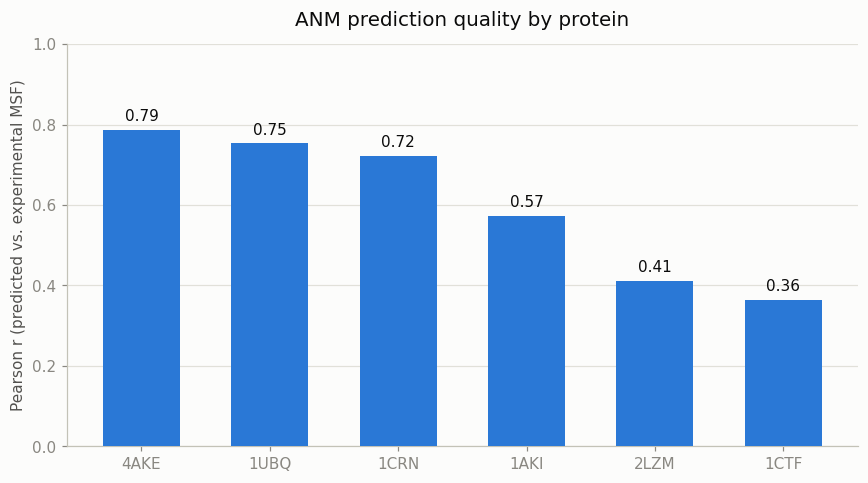

In [5]:
BLUE = "#2a78d6"
INK = "#0b0b0b"
INK_SECONDARY = "#52514e"
INK_MUTED = "#898781"
GRIDLINE = "#e1e0d9"
AXIS = "#c3c2b7"
SURFACE = "#fcfcfb"

sorted_df = df.sort_values("Pearson r", ascending=False)

fig, ax = plt.subplots(figsize=(8, 4.5))
fig.patch.set_facecolor(SURFACE)
ax.set_facecolor(SURFACE)

bars = ax.bar(sorted_df.index, sorted_df["Pearson r"], color=BLUE, width=0.6, zorder=3)

for bar, value in zip(bars, sorted_df["Pearson r"]):
    ax.text(bar.get_x() + bar.get_width() / 2, value + 0.015, f"{value:.2f}",
            ha="center", va="bottom", color=INK, fontsize=10)

ax.set_ylim(0, 1.0)
ax.set_ylabel("Pearson r (predicted vs. experimental MSF)", color=INK_SECONDARY)
ax.set_title("ANM prediction quality by protein", color=INK, fontsize=13, pad=12)
ax.tick_params(colors=INK_MUTED)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color(AXIS)
ax.spines["bottom"].set_color(AXIS)
ax.yaxis.grid(True, color=GRIDLINE, linewidth=0.8, zorder=0)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()


## Correlation vs. protein size

Does prediction quality depend on how large the structure is?


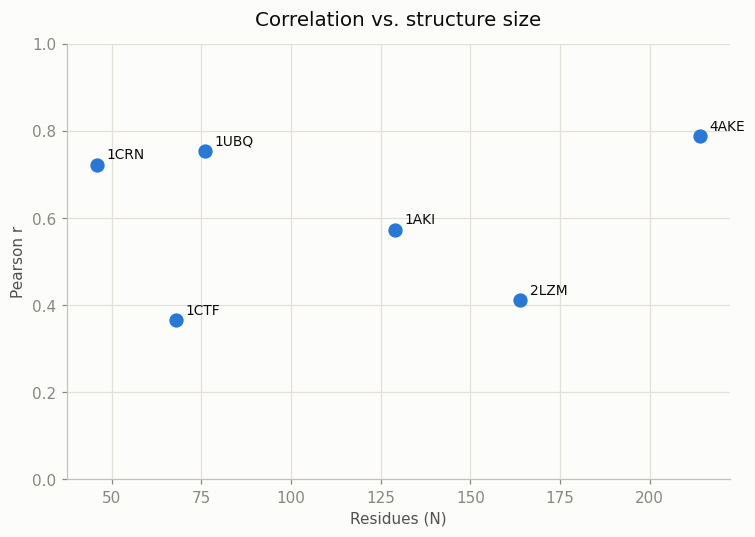

In [6]:
fig, ax = plt.subplots(figsize=(7, 5))
fig.patch.set_facecolor(SURFACE)
ax.set_facecolor(SURFACE)

ax.scatter(df["Residues"], df["Pearson r"], s=70, color=BLUE, zorder=3)
for pdb_id, row in df.iterrows():
    ax.annotate(pdb_id, (row["Residues"], row["Pearson r"]),
                textcoords="offset points", xytext=(6, 4), color=INK, fontsize=9)

ax.set_xlabel("Residues (N)", color=INK_SECONDARY)
ax.set_ylabel("Pearson r", color=INK_SECONDARY)
ax.set_title("Correlation vs. structure size", color=INK, fontsize=13, pad=12)
ax.set_ylim(0, 1.0)
ax.tick_params(colors=INK_MUTED)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color(AXIS)
ax.spines["bottom"].set_color(AXIS)
ax.grid(True, color=GRIDLINE, linewidth=0.8, zorder=0)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()


No strong size trend across this small sample -- 4AKE (214 residues) has the
*highest* correlation, not the lowest, and the two lowest-scoring structures
(2LZM, 1CTF) are mid-sized rather than the largest. Whatever is driving the
spread here, it isn't simply "bigger protein, worse prediction."


## Case study: adenylate kinase (4AKE) hinge motion

4AKE is a classic normal-mode-analysis structure because of its large-scale,
low-frequency hinge motion between its NMP-binding, LID, and CORE domains. A
high correlation here, combined with a highly collective lead mode, is a
reasonable check that the model is recovering biologically meaningful
motion, not just noise.


4AKE lead mode collectivity: 0.410 (1.0 = fully collective across all 214 residues, 0.005 = localized to a single residue)


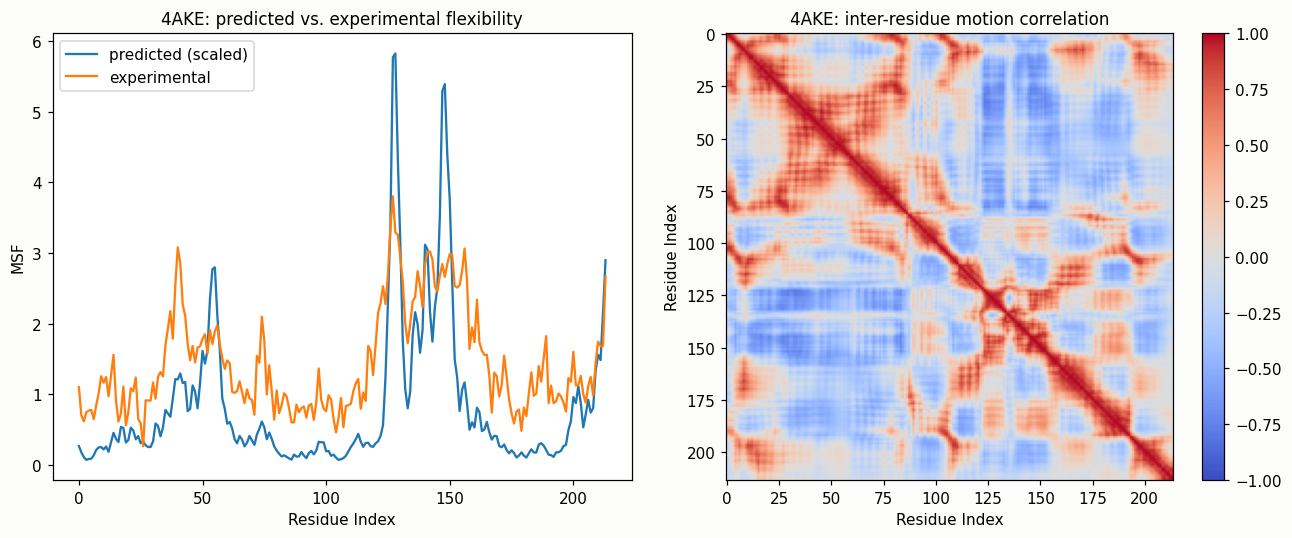

In [7]:
akr = results["4AKE"]
N4 = akr.coords.shape[0]
cov4 = anm.compute_covariance(akr.kept_vals, akr.kept_vecs, N4)
exp_msf4 = bfactor_to_msf(akr.bfactors)

fig = plt.figure(figsize=(12, 5))
fig.patch.set_facecolor(SURFACE)

ax1 = fig.add_subplot(1, 2, 1)
plt.sca(ax1)
anm.plot_msf_overlay(akr.msf * akr.scale, exp_msf4)
ax1.set_title("4AKE: predicted vs. experimental flexibility", fontsize=11)

ax2 = fig.add_subplot(1, 2, 2)
plt.sca(ax2)
anm.plot_correlation_heatmap(cov4, N4)
ax2.set_title("4AKE: inter-residue motion correlation", fontsize=11)

plt.tight_layout()
plt.show()

print(f"4AKE lead mode collectivity: {akr.collectivity[0]:.3f} "
      f"(1.0 = fully collective across all {N4} residues, "
      f"{1/N4:.3f} = localized to a single residue)")


The lead mode's collectivity is well above the fully-localized floor,
consistent with a motion spread across a large fraction of the structure --
the kind of behavior expected of a domain-hinge mechanism rather than a
single flexible loop.


## Discussion

Pearson correlations across the six structures ranged from about 0.4 to 0.8.
A few observations:

- **4AKE and 1UBQ scored highest.** Both are well-studied structures where
  the dominant motions (domain hinging for 4AKE, general backbone
  flexibility for ubiquitin) are exactly the kind of large-scale, low-frequency
  motion an elastic network model is built to capture.
- **2LZM and 1CTF scored lowest.** This notebook doesn't establish *why* --
  that would require checking each structure's resolution, refinement
  protocol, and crystal contacts individually. B-factors are influenced by
  crystal packing and by how B-factors were modeled during refinement (single
  isotropic value per atom vs. anisotropic vs. TLS groups), none of which the
  ANM knows about since it only sees the coordinates. A low correlation here
  is not necessarily a model failure -- it may just as easily mean the
  experimental B-factors are a noisier proxy for intrinsic flexibility in
  that particular deposited structure. Distinguishing those two explanations
  is a natural next step, not a conclusion this notebook can draw on its own.
- **No size trend.** Correlation quality did not scale with residue count
  across this sample, suggesting size alone is not the dominant factor here.

## Limitations

- **Small, non-random sample.** Six structures chosen for being classic,
  well-known systems, not a systematic benchmark. A rigorous validation
  would use a curated set of 50-100+ structures spanning fold classes and
  resolutions, as done in the published ANM literature.
- **Single parameter set.** Every structure used the same `cutoff=8.0`,
  `gamma=1.0`. Published ANM work often tunes these per structure; a
  parameter sweep showing how correlation responds to cutoff/gamma would be
  a natural follow-up.
- **B-factors as ground truth.** B-factors conflate genuine thermal/dynamic
  flexibility with static disorder and crystal-packing artifacts. A stronger
  validation would also compare against independent dynamics data -- e.g. an
  NMR ensemble's per-residue RMSF, or an MD trajectory -- neither of which
  this notebook attempts.

## References

- Atilgan, A.R., Durell, S.R., Jernigan, R.L., Demirel, M.C., Keskin, O., &
  Bahar, I. (2001). Anisotropic network model. *Biophysical Journal*.
- Eyal, E., Yang, L.W., & Bahar, I. (2006). Anisotropic network model:
  systematic evaluation and a new web interface. *Bioinformatics*.
